# <font color = 'indianred'>**Multilabel Classification of StackExchange Dataset using GEMMA** </font>

**Objective:**<br>
Demonstrate inference and evaluation of a base Gemma-2-2B model for a multilabel text classification task on the StackExchange dataset using vLLM.
The notebook shows how to: <br>

1. Perform guided (constrained) decoding via JSON schema enforcement to produce structured label outputs.<br>
2. Generate predictions with vLLM’s high-performance inference engine.<br>
3. Evaluate results using multilabel metrics (macro F1) and visualize performance through confusion matrices.<br>
4. Log validation and test performance to Weights & Biases (WandB) for experiment tracking.<br>

**Plan**

1. Set Environment
2. Load Dataset
3. Download Model and setup vLLM
4. Setup WandB
5. Validation
6. Performance on Test Set
























# <font color = 'indianred'> **1. Setting up the Environment** </font>



In [54]:
# If in Colab, then import the drive module from google.colab
if 'google.colab' in str(get_ipython()):
  !pip install numpy -U -qq
  !pip install transformers evaluate wandb datasets accelerate trl peft bitsandbytes  -U -qq
  !pip install vllm==0.11.2
  !pip uninstall tensorflow -y -qq

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.3.5 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.
  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installa

ERROR: Operation cancelled by user
^C


 <Font size = 5 color = 'indianred'>**Restart the session before moving onto next cell**
> Runtime- Restart Session

<font color = 'indianred'> *Load Libraries* </font>

In [1]:
import os
os.environ['VLLM_USE_V1'] = '1' # this should be done befre any other import

import torch
import torch.nn as nn
from vllm import LLM, SamplingParams
from vllm.lora.request import LoRARequest
from vllm.sampling_params import GuidedDecodingParams

In [2]:
# standard pythgion libraries
from pathlib import Path

from typing import Dict, List, Union, Optional, Tuple
from tqdm import tqdm
import json
import os
import sys

# Data Science librraies
import numpy as np
import pandas as pd
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
from pprint import pprint

# Pytorch
import torch

# Huggingface Librraies
import evaluate
from datasets import load_dataset

from huggingface_hub import login

# Logging and secrets
import wandb
from google.colab import userdata
from huggingface_hub import login, HfApi, create_repo

In [3]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/nvidia_cutlass_dsl/python_packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython',
 '/tmp/tmpu62mgkyl']

In [4]:
# If running on Google Colab, use Google Drive as storage
# CHANGE FOLDERS TO WHERE YOU WANT TO SAVE DATA AND MODELS

if 'google.colab' in str(get_ipython()):
    from google.colab import drive  # Import Google Drive mounting utility
    drive.mount('/content/drive')  # Mount Google Drive

    # Set base folder path for storing data on Google Drive
    project_folder = Path('/content/drive/MyDrive')

# If running locally, specify a different path
else:
    # Set base folder path for storing data on local machine
     data_folder= Path('/home/harpreet/Insync/google_drive_shaannoor/teaching_fall_2025/LLM_Fall_2025/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
util_folder = project_folder/'shared_utils'

In [6]:
sys.path.append(str(util_folder))

In [7]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/nvidia_cutlass_dsl/python_packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython',
 '/tmp/tmpu62mgkyl',
 '/content/drive/MyDrive/shared_utils']

In [8]:
from shared_utils import free_gpu_memory,  multilabel_evaluation

In [9]:
wandb_api_key = userdata.get('WANDB_API_KEY')
hf_token = userdata.get('HF_TOKEN')

In [10]:
if hf_token:
    # Log in to Hugging Face
    login(token=hf_token)
    print("Successfully logged in to Hugging Face!")
else:
    print("Hugging Face token not found in notebook secrets.")

Successfully logged in to Hugging Face!


In [11]:
if wandb_api_key:
  wandb.login(key=wandb_api_key)
  print("Successfully logged in to WANDB!")
else:
    print("WANDB key not found in notebook secrets.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: younes-hoseini67 (younes-hoseini67-university-of-texas-at-dallas) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Successfully logged in to WANDB!


# <font color = 'indianred'> **2. Load Data set**
    


In [12]:
from datasets import load_dataset
from pprint import pprint

# Load validation and test splits
val_split = load_dataset("sayedyounes/stack_multilabel_subset_completion", split="valid")
test_split = load_dataset("sayedyounes/stack_multilabel_subset_completion", split="test")

# Extract prompts
val_prompts = val_split['prompt']
test_prompts = test_split['prompt']

# Quick check
pprint(val_split[0])


{'completion': ' ["anger", "disgust", "sadness"]',
 'prompt': 'Classify the TEXT by selecting all applicable labels from the '
           "following list: ['anger', 'anticipation', 'disgust', 'fear', "
           "'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', "
           "'trust']. ### TEXT: @ChrisChristie You have no Police "
           'credentials-You were a litigator. Nothing more-No Experience.#Sad '
           '#TrumpPuppet #Felon #bully #jersey4sale ### LABEL:'}


#  <font color = 'indianred'> **3. Download Model and setup vLLM**

In [13]:
torch.cuda.empty_cache()
BASE_MODEL = "google/gemma-2-2b"
LORA_ADAPTER = "Sayedyounes/stack_exc_multilabel_base_lm_head"

In [14]:
llm = LLM(
    model=BASE_MODEL,
    dtype=torch.bfloat16,
    trust_remote_code=True,
    quantization="bitsandbytes",
    enable_lora=True,
    max_lora_rank=128,
    gpu_memory_utilization=0.8,
    guided_decoding_backend="outlines",
)


INFO 12-14 02:42:00 [utils.py:253] non-default args: {'trust_remote_code': True, 'dtype': torch.bfloat16, 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'quantization': 'bitsandbytes', 'enable_lora': True, 'max_lora_rank': 128, 'guided_decoding_backend': 'outlines', 'model': 'google/gemma-2-2b'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 12-14 02:42:01 [model.py:631] Resolved architecture: Gemma2ForCausalLM
INFO 12-14 02:42:01 [model.py:1968] Downcasting torch.float32 to torch.bfloat16.
INFO 12-14 02:42:01 [model.py:1745] Using max model len 8192
INFO 12-14 02:42:01 [scheduler.py:216] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 12-14 02:42:04 [system_utils.py:103] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 12-14 02:43:20 [llm.py:352] Supported tasks: ['generate']


In [15]:

lora_request = LoRARequest(
    lora_name="stack_classifier",
    lora_int_id=1,
    lora_path=LORA_ADAPTER
)


class_names = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
               'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

array_schema = {
    "type": "array",
    "items": {
        "type": "string",
        "enum": class_names
    },
    "minItems": 0,
    "maxItems": 11,
}

guided_decoding = GuidedDecodingParams(
    json=array_schema,
    backend="outlines"
)

sampling_params = SamplingParams(
    temperature=0,
    max_tokens=20,
    guided_decoding=guided_decoding,
)

/tmp/ipython-input-818446816.py:26: DeprecationWarning: guided_decoding is deprecated. This will be removed in v0.12.0 or v1.0.0, which ever is soonest. Please use structured_outputs instead.
  sampling_params = SamplingParams(


# <font color = 'indianred'> **4. Setup WandB**</font>

In [16]:
%env WANDB_PROJECT = emotion-detection

run = wandb.init(
    project="emotion-detection",
    name="partB_inference_vllm",
    tags=["part-b", "inference", "vllm"],
    notes="Part B inference using vLLM with constrained decoding"
)

env: WANDB_PROJECT=emotion-detection


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


#<font color = 'indianred'> **5. Utility Functions**

In [32]:
def generate_predictions_batch(prompts: List[str],
                               llm: LLM,
                               sampling_params: SamplingParams,
                               lora_request: LoRARequest,
                               batch_size: int = 64) -> List[List[str]]:
    """
    Generate predictions for a list of prompts using vLLM batch inference.

    Returns a list of predicted labels (as lists of strings), safely parsed.
    """
    predictions = []

    for i in tqdm(range(0, len(prompts), batch_size), desc="Generating predictions"):
        batch = prompts[i:i+batch_size]

        outputs = llm.generate(
            batch,
            sampling_params,
            lora_request=lora_request
        )

        for output in outputs:
            text = output.outputs[0].text
            # Use robust parser
            pred = parse_label_string(text)
            predictions.append(pred)

    print(f"Processed {len(predictions)}/{len(prompts)} prompts")
    return predictions


In [42]:
def parse_label_string(label_str: str) -> List[str]:
    """Parse model output JSON list of labels."""
    try:
        return json.loads(label_str.strip())
    except json.JSONDecodeError:
        return []


In [18]:
# def parse_label_string(label_str: str) -> List[str]:
#     """Parse label string to list of labels."""
#     try:
#         return json.loads(label_str.strip())
#     except:
#         return []


In [43]:
f1 = evaluate.load('f1','multilabel')
def compute_metrics( labels, preds):
  f1_macro = f1.compute(predictions=preds, references=labels, average='macro')
  return {'f1_macro':f1_macro['f1'],}

In [44]:
def evaluate_multilabel_predictions(true_labels: Union[List[str], List[List[str]]],
                                     predictions: List[List[str]],
                                     class_names: List[str],
                                     split_name: str = "valid",
                                     log_to_wandb: bool = True,
                                     show_confusion_matrix: bool = True) -> Dict:
    """
    Evaluate multilabel predictions and optionally log to wandb.

    Args:
        true_labels: List of label strings OR list of label lists
        predictions: List of predicted label lists
        class_names: List of all possible class names
        split_name: Name of the split (for wandb logging)
        log_to_wandb: Whether to log metrics to wandb
        show_confusion_matrix: Whether to display confusion matrix

    Returns:
        Dictionary containing evaluation metrics
    """
    # Parse true labels only if they are strings
    if len(true_labels) > 0 and isinstance(true_labels[0], str):
        parsed_labels = [parse_label_string(label) for label in true_labels]
        print(f"Parsed string labels to lists")
    else:
        parsed_labels = true_labels
        print(f"Labels already in list format")

    # Initialize MultiLabelBinarizer
    mlb = MultiLabelBinarizer(classes=class_names)
    mlb.fit([class_names])  # Fit with all possible classes

    # Transform to binary format
    labels_binary = mlb.transform(parsed_labels)
    predictions_binary = mlb.transform(predictions)

    # Print samples and shapes
    print(f"\n{'='*60}")
    print(f"{split_name.upper()} SET EVALUATION")
    print(f"{'='*60}")
    print(f"Sample true labels: {parsed_labels[:3]}")
    print(f"Sample predictions: {predictions[:3]}")
    print(f"\nBinary shapes:")
    print(f"  Labels:      {labels_binary.shape}")
    print(f"  Predictions: {predictions_binary.shape}")

    # Compute metrics
    metrics = compute_metrics(labels_binary, predictions_binary)
    print(f"\nMetrics:")
    print(f"  F1 Macro: {metrics['f1_macro']:.4f}")

    # Log to wandb
    if log_to_wandb:
        wandb.log({f"{split_name}_f1_macro": metrics["f1_macro"]})
        print(f"  ✓ Logged to wandb")

    # Display confusion matrix
    if show_confusion_matrix:
        print(f"\nConfusion Matrix:")
        multilabel_evaluation(
            y_true=labels_binary,
            y_pred=predictions_binary,
            class_names=class_names,
            figsize=(12, 8)
        )

    return metrics

#<font color = 'indianred'> **6. Performance on Validation Set**

<font color = 'indianred'> *Evaluate model on Validation Set* </font>


In [45]:
# Define class names (used for both validation and test)
print(f"Using {len(class_names)} emotion classes: {class_names}")

Using 11 emotion classes: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']


In [46]:
val_prompts = val_split['prompt']
len(val_prompts)

1545

In [47]:
val_predictions = generate_predictions_batch(
    prompts=val_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=64
)

Generating predictions:   0%|          | 0/25 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/64 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/64 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions:   4%|▍         | 1/25 [00:00<00:14,  1.71it/s]

Adding requests:   0%|          | 0/64 [00:00<?, ?it/s]

...

Generating predictions:  96%|█████████▌| 24/25 [00:13<00:00,  1.79it/s]

Adding requests:   0%|          | 0/9 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/9 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 25/25 [00:13<00:00,  1.81it/s]

Processed 1545/1545 prompts


In [48]:
val_predictions[0:5]

[['anger', 'disgust', 'sadness'],
 ['anticipation', 'joy', 'optimism'],
 ['joy', 'optimism'],
 ['joy', 'love', 'optimism'],
 ['anger', 'disgust', 'fear', 'sadness']]

Parsed string labels to lists

VALID SET EVALUATION
Sample true labels: [['anger', 'disgust', 'sadness'], ['anticipation', 'joy', 'optimism'], ['anticipation', 'disgust', 'joy']]
Sample predictions: [['anger', 'disgust', 'sadness'], ['anticipation', 'joy', 'optimism'], ['joy', 'optimism']]

Binary shapes:
  Labels:      (1545, 11)
  Predictions: (1545, 11)

Metrics:
  F1 Macro: 0.5116
  ✓ Logged to wandb

Confusion Matrix:


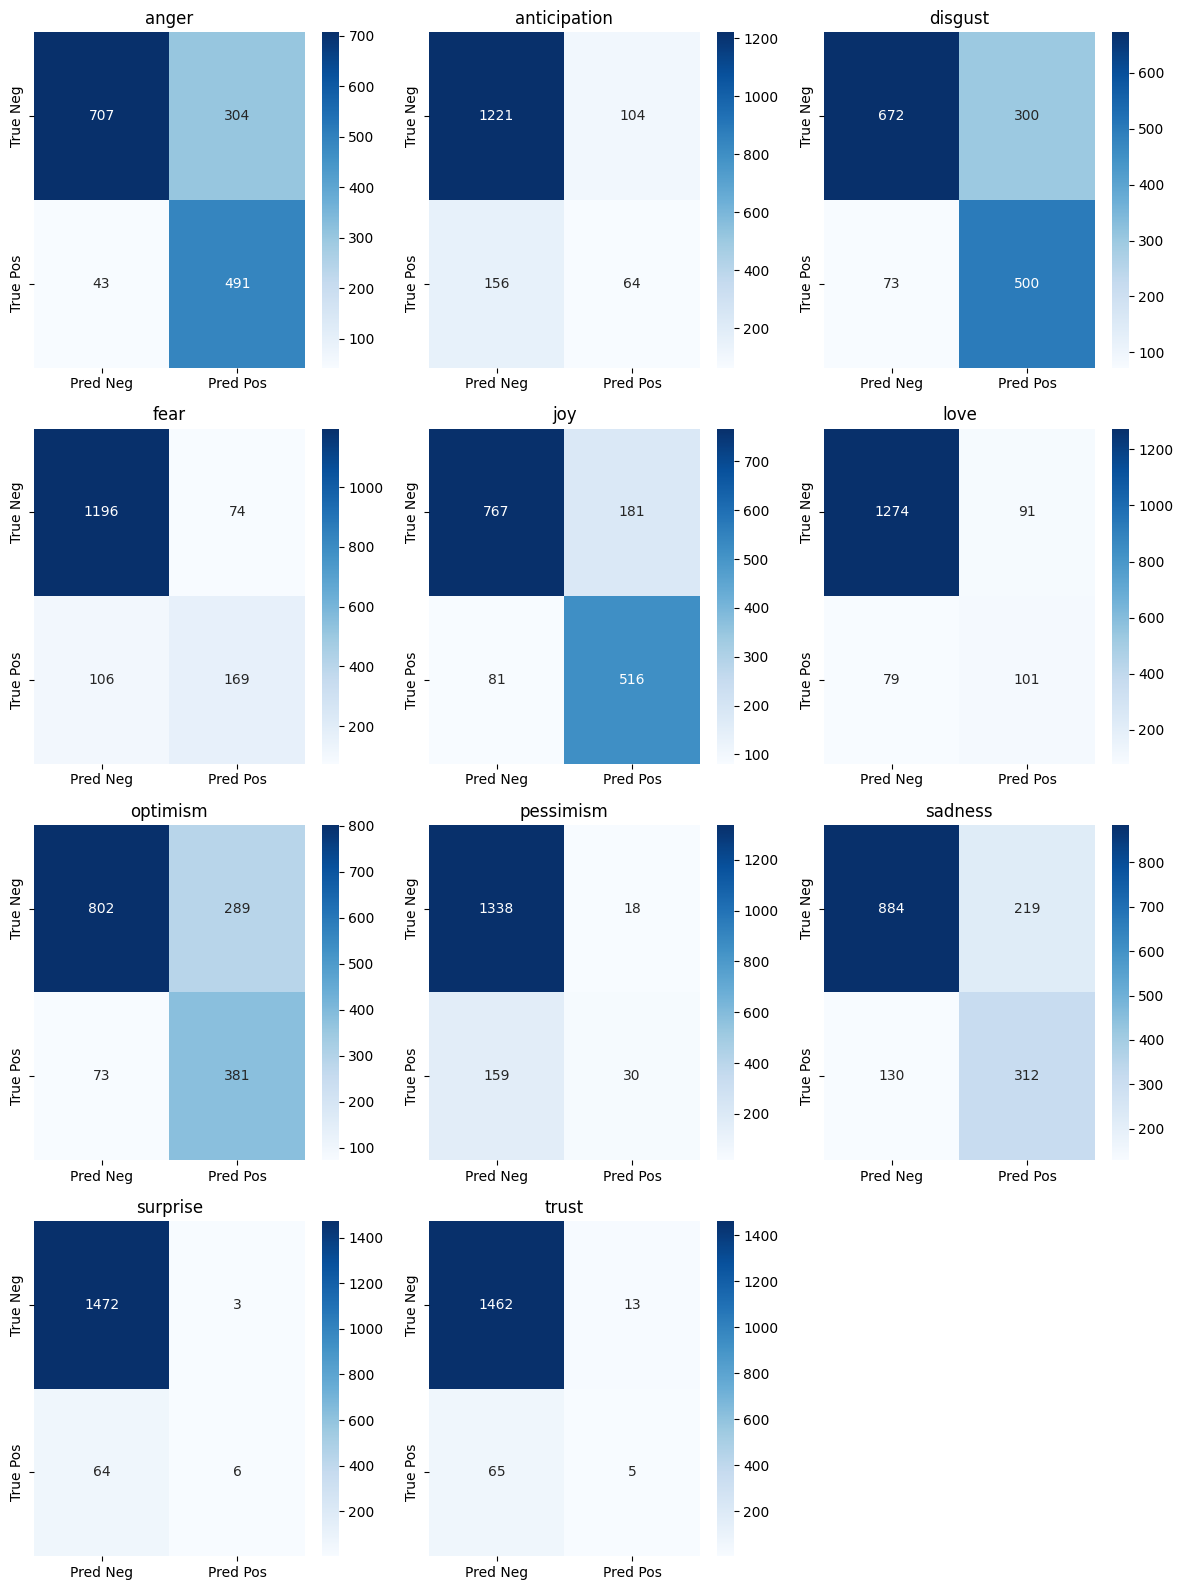

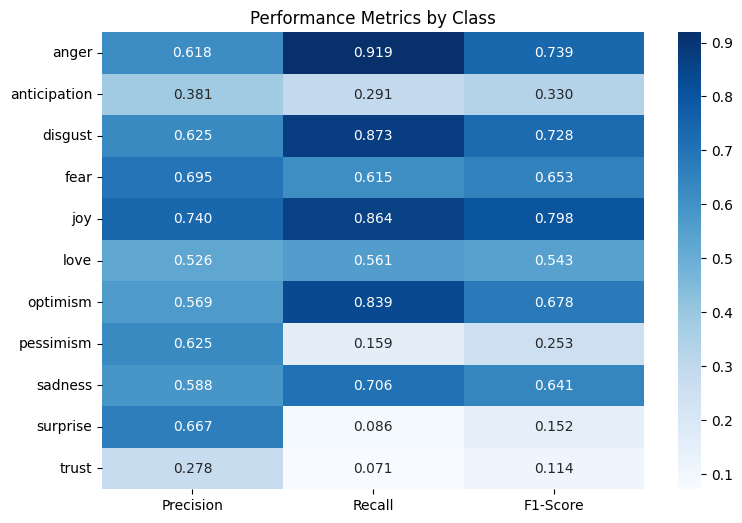

<Figure size 1200x533.333 with 0 Axes>

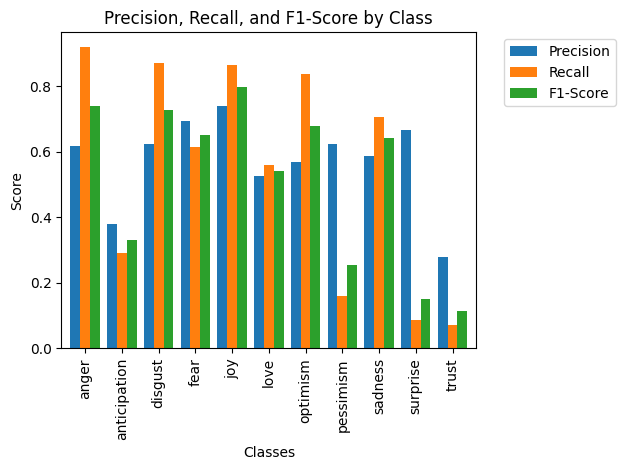

In [49]:
# Evaluate
valid_metrics = evaluate_multilabel_predictions(
    true_labels=val_split['completion'],
    predictions=val_predictions,
    class_names=class_names,
    split_name="valid",
    log_to_wandb=True,
    show_confusion_matrix=True
)

#  <font color = 'indianred'> **7. Performance on Test Set** </font>
For test set evaluation, we will perfrom following steps:



In [50]:
# Generate predictions
test_predictions = generate_predictions_batch(
    prompts=test_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=64
)

Generating predictions:   0%|          | 0/25 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/64 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/64 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions:   4%|▍         | 1/25 [00:00<00:17,  1.36it/s]

Adding requests:   0%|          | 0/64 [00:00<?, ?it/s]

...

Generating predictions:  96%|█████████▌| 24/25 [00:16<00:00,  1.45it/s]

Adding requests:   0%|          | 0/9 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/9 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 25/25 [00:17<00:00,  1.45it/s]

Processed 1545/1545 prompts


Parsed string labels to lists

TEST SET EVALUATION
Sample true labels: [['joy', 'love'], ['joy'], ['joy', 'love', 'optimism']]
Sample predictions: [['joy', 'love', 'optimism'], ['joy', 'optimism'], ['joy', 'love', 'optimism']]

Binary shapes:
  Labels:      (1545, 11)
  Predictions: (1545, 11)

Metrics:
  F1 Macro: 0.5117
  ✓ Logged to wandb

Confusion Matrix:


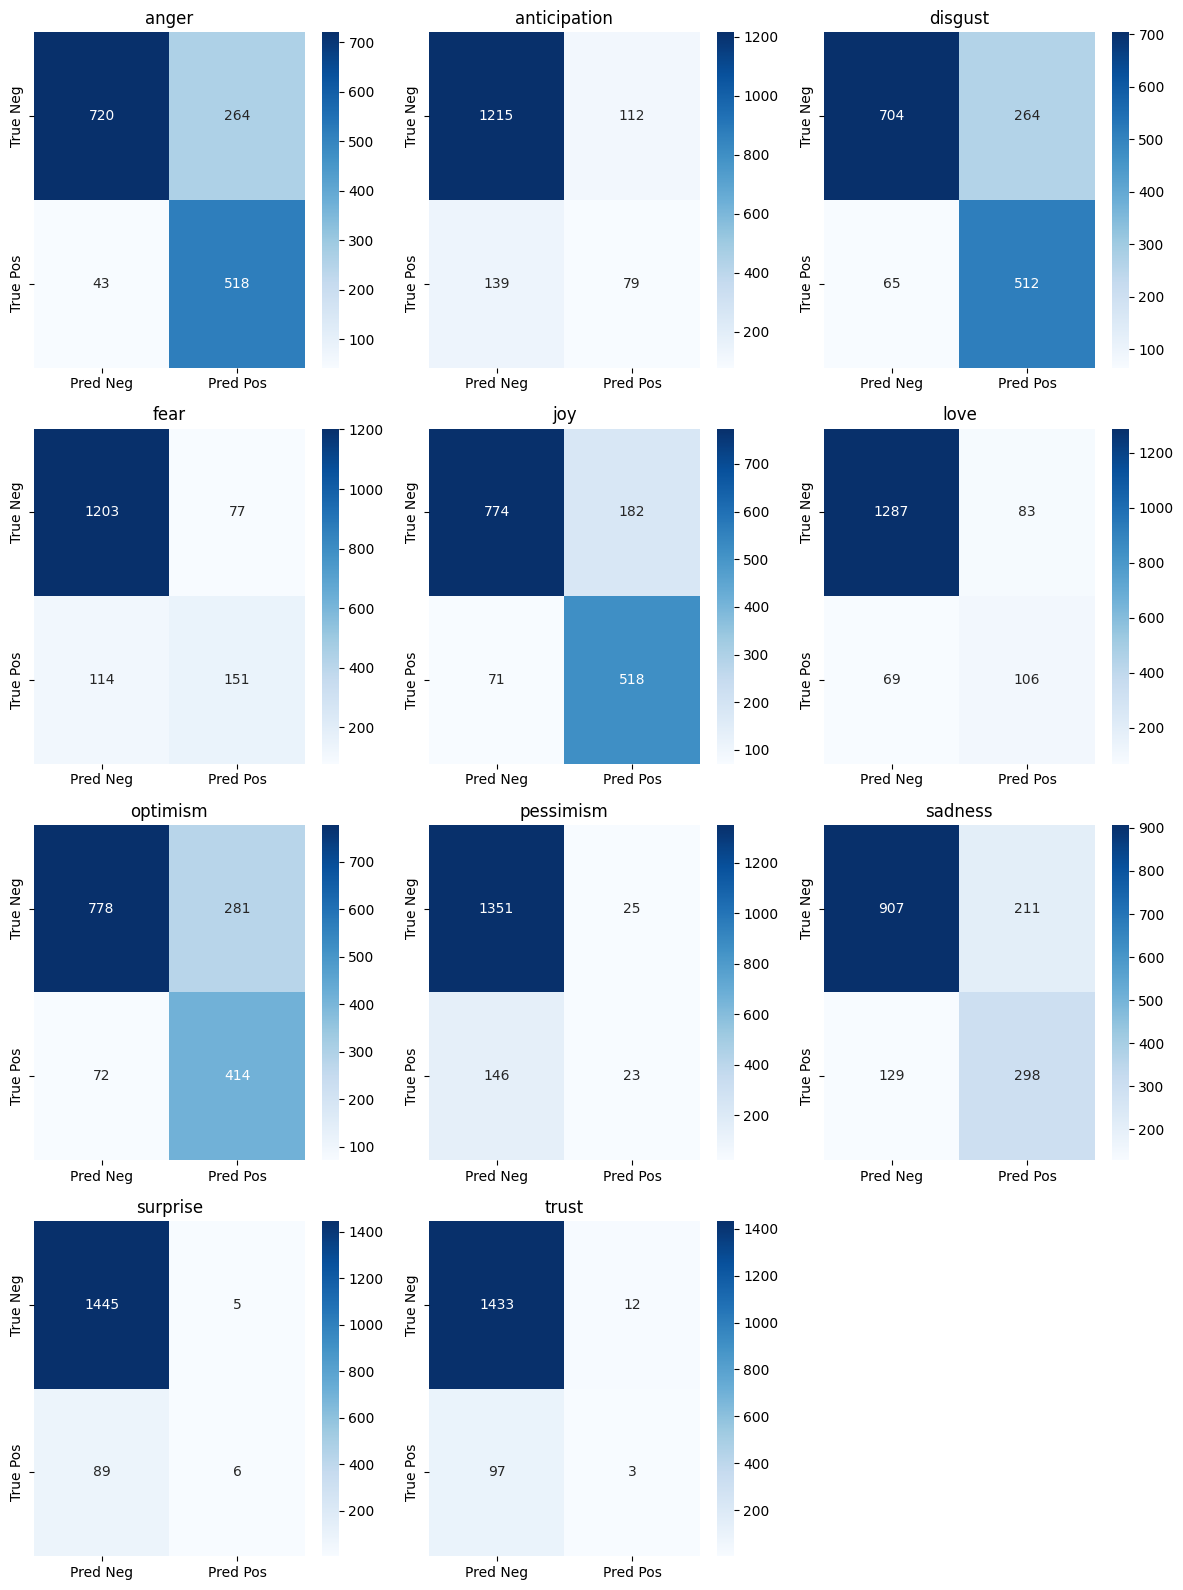

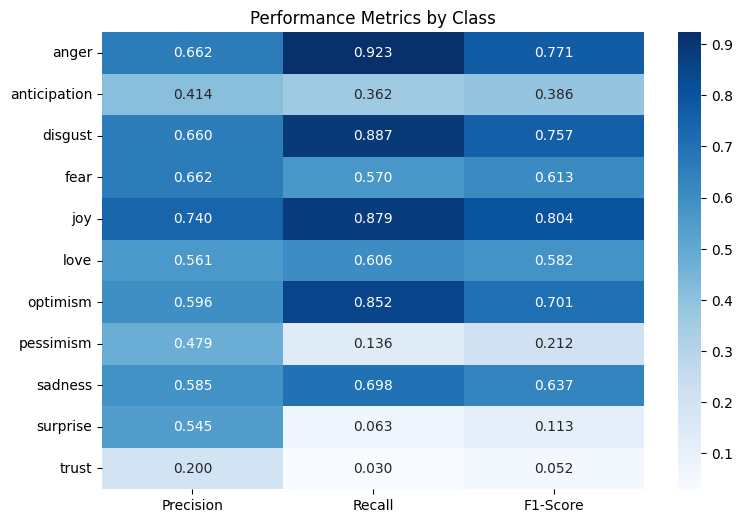

<Figure size 1200x533.333 with 0 Axes>

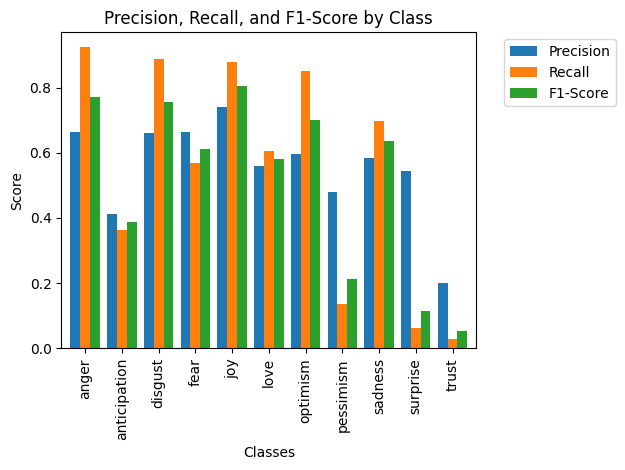

In [51]:
# Evaluate
test_metrics = evaluate_multilabel_predictions(
    true_labels=test_split['completion'],
    predictions=test_predictions,
    class_names=class_names,
    split_name="test",
    log_to_wandb=True,
    show_confusion_matrix=True
)


In [52]:
# Finish wandb run
wandb.finish()

test_f1_macro,▁
valid_f1_macro,▁█
test_f1_macro,0.51168
valid_f1_macro,0.51165


In [53]:
text = val_split['prompt'][0]
text

"Classify the TEXT by selecting all applicable labels from the following list: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']. ### TEXT: @ChrisChristie You have no Police credentials-You were a litigator. Nothing more-No Experience.#Sad #TrumpPuppet #Felon #bully #jersey4sale ### LABEL:"

# <font color = 'indianred'> **8. Inference** </font>

<font color = 'indianred'> *Demonstrate inference on a single text input* </font>


## <font color = 'indianred'> Example 1: Single text *inference* </font>


In [54]:
# Example Single text input - emotion tweet
text_1 = "I am so excited and happy about the new project! Can't wait to get started!"

In [55]:
def create_prompt_for_single_text(text: str) -> str:
    """
    Create a prompt for a single text input for classification.

    Args:
        text: Input text to classify

    Returns:
        Formatted prompt string
    """
    prompt = f"""Classify the TEXT by selecting all applicable labels from the following list: ['anger', 'anticipation', 'disgust', 'fear', 'joy',
               'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust'].

TEXT: {text}"""

    return prompt

In [56]:
# Create prompt
prompt_1 = create_prompt_for_single_text(text_1)

In [57]:
prompt_1

"Classify the TEXT by selecting all applicable labels from the following list: ['anger', 'anticipation', 'disgust', 'fear', 'joy',\n               'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust'].\n\nTEXT: I am so excited and happy about the new project! Can't wait to get started!"

In [58]:
prediction_1 = generate_predictions_batch(
    prompts=[prompt_1],  # Single prompt as a list
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=1
)

Generating predictions:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 1/1 [00:00<00:00,  7.92it/s]

Processed 1/1 prompts


In [59]:
prediction_1

[['joy', 'optimism']]

## <font color = 'indianred'> Example 2: Multiple custom texts at once </font>


In [60]:
#Example 2: Multiple custom texts at once

# Multiple emotion tweets
custom_texts = [
    "I'm feeling really anxious about the exam tomorrow",
    "What a beautiful day! Everything is going perfectly!",
    "I can't believe they did that. I'm so angry right now.",
    "Worried about the future but trying to stay optimistic"
]
# Create prompts
custom_prompts = [create_prompt_for_single_text(text) for text in custom_texts]

# Predict using existing function
custom_predictions = generate_predictions_batch(
    prompts=custom_prompts,
    llm=llm,
    sampling_params=sampling_params,
    lora_request=lora_request,
    batch_size=64
)

# Display results
print("Batch Inference Results:")
print("="*60)
for text, pred in zip(custom_texts, custom_predictions):
    print(f"\nText: {text}")
    print(f"Predicted Labels: {pred}")
    print("-"*60)


Generating predictions:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests:   0%|          | 0/4 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/4 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating predictions: 100%|██████████| 1/1 [00:00<00:00,  3.92it/s]

Processed 4/4 prompts
Batch Inference Results:

Text: I'm feeling really anxious about the exam tomorrow
Predicted Labels: []
------------------------------------------------------------

Text: What a beautiful day! Everything is going perfectly!
Predicted Labels: ['joy', 'optimism']
------------------------------------------------------------

Text: I can't believe they did that. I'm so angry right now.
Predicted Labels: ['anger', 'disgust']
------------------------------------------------------------

Text: Worried about the future but trying to stay optimistic
Predicted Labels: []
------------------------------------------------------------
